# Pergunta 10 - Efetividade do Programa

Objetivo:

Avaliar a evolução dos estudantes entre 2022, 2023 e 2024 para identificar evidências da efetividade do programa.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving BASE DE DADOS PEDE 2024 - DATATHON.xlsx to BASE DE DADOS PEDE 2024 - DATATHON.xlsx


In [3]:
arquivo = list(uploaded.keys())[0]

df2022 = pd.read_excel(arquivo, sheet_name='PEDE2022')
df2023 = pd.read_excel(arquivo, sheet_name='PEDE2023')
df2024 = pd.read_excel(arquivo, sheet_name='PEDE2024')

print("Bases carregadas.")

Bases carregadas.


In [4]:
ra2022 = set(df2022['RA'])
ra2023 = set(df2023['RA'])
ra2024 = set(df2024['RA'])

alunos_3_anos = (
    ra2022
    .intersection(ra2023)
    .intersection(ra2024)
)

len(alunos_3_anos)

468

In [5]:
print(f'Alunos presentes nos 3 anos: {len(alunos_3_anos)}')

Alunos presentes nos 3 anos: 468


In [6]:
df2022_3anos = df2022[df2022['RA'].isin(alunos_3_anos)].copy()
df2023_3anos = df2023[df2023['RA'].isin(alunos_3_anos)].copy()
df2024_3anos = df2024[df2024['RA'].isin(alunos_3_anos)].copy()

print(df2022_3anos.shape)
print(df2023_3anos.shape)
print(df2024_3anos.shape)


(468, 42)
(468, 48)
(468, 50)


In [7]:
print("INDE 2022")
print(df2022_3anos['INDE 22'].describe())

print("\n" + "="*50 + "\n")

print("INDE 2023")
print(df2023_3anos['INDE 2023'].describe())

print("\n" + "="*50 + "\n")

print("INDE 2024")
print(pd.to_numeric(
    df2024_3anos['INDE 2024'],
    errors='coerce'
).describe())

INDE 2022
count    468.000000
mean       7.381748
std        0.839927
min        3.898000
25%        6.917000
50%        7.482000
75%        7.989250
max        9.442000
Name: INDE 22, dtype: float64


INDE 2023
count    443.000000
mean       7.358370
std        0.851204
min        4.406458
25%        6.759150
50%        7.462867
75%        7.983417
max        9.013867
Name: INDE 2023, dtype: float64


INDE 2024
count    441.000000
mean       7.383332
std        1.079584
min        3.835478
25%        6.713501
50%        7.467501
75%        8.243183
max        9.437925
Name: INDE 2024, dtype: float64


In [8]:
inde_medios = pd.DataFrame({

    'Ano': [2022, 2023, 2024],

    'INDE Médio': [

        df2022_3anos['INDE 22'].mean(),

        df2023_3anos['INDE 2023'].mean(),

        pd.to_numeric(
            df2024_3anos['INDE 2024'],
            errors='coerce'
        ).mean()
    ]
})

inde_medios

,Ano,INDE Médio
0,2022,7.381748
1,2023,7.358370
2,2024,7.383332


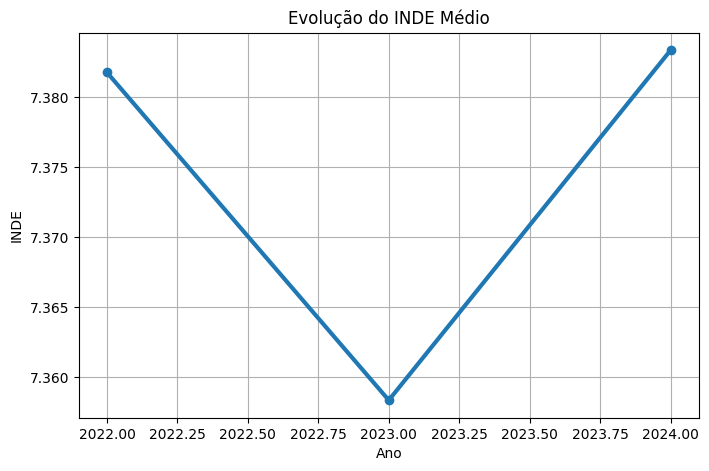

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    inde_medios['Ano'],
    inde_medios['INDE Médio'],
    marker='o',
    linewidth=3
)

plt.title('Evolução do INDE Médio')
plt.ylabel('INDE')
plt.xlabel('Ano')

plt.grid(True)

plt.show()

In [10]:
inde22 = df2022_3anos[['RA','INDE 22']].copy()

inde24 = df2024_3anos[['RA','INDE 2024']].copy()

inde24['INDE 2024'] = pd.to_numeric(
    inde24['INDE 2024'],
    errors='coerce'
)

evolucao = inde22.merge(
    inde24,
    on='RA'
)

evolucao['Variacao_INDE'] = (
    evolucao['INDE 2024']
    -
    evolucao['INDE 22']
)

evolucao.head()

,RA,INDE 22,INDE 2024,Variacao_INDE
0,RA-1,5.783,NaN,NaN
1,RA-2,7.055,NaN,NaN
2,RA-6,5.848,NaN,NaN
3,RA-7,6.818,NaN,NaN
4,RA-12,4.832,NaN,NaN


In [11]:
evolucao['Variacao_INDE'].describe()

,Variacao_INDE
count,441.000000
mean,-0.007881
std,0.902546
min,-3.898600
25%,-0.481815
50%,0.063478
75%,0.612811
max,2.210181


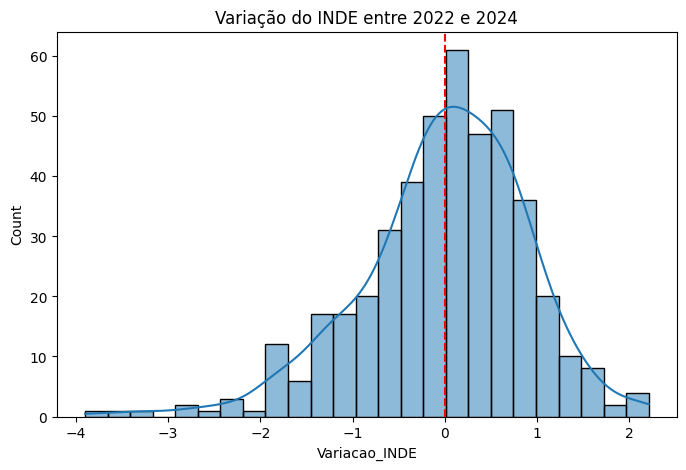

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    evolucao['Variacao_INDE'],
    bins=25,
    kde=True
)

plt.axvline(
    0,
    color='red',
    linestyle='--'
)

plt.title('Variação do INDE entre 2022 e 2024')

plt.show()

In [13]:
print(
    "Melhoraram:",
    (evolucao['Variacao_INDE'] > 0).sum()
)

print(
    "Pioraram:",
    (evolucao['Variacao_INDE'] < 0).sum()
)

print(
    "Sem alteração:",
    (evolucao['Variacao_INDE'] == 0).sum()
)

Melhoraram: 242
Pioraram: 199
Sem alteração: 0


## Evolução Individual do INDE (2022–2024)

Foram analisados os estudantes presentes nos três anos da base.

Total analisado:

441 estudantes com INDE disponível em 2022 e 2024.

### Resultados

| Situação | Quantidade |
|-----------|----------:|
| Melhoraram | 242 |
| Pioraram | 199 |

### Insight Executivo

Embora o INDE médio tenha permanecido relativamente estável ao longo do período, a análise individual demonstra que a maioria dos estudantes apresentou evolução positiva.

Os resultados sugerem evidências de efetividade do programa, com aproximadamente 55% dos estudantes melhorando seu desempenho educacional entre 2022 e 2024.

In [14]:
evolucao['Status'] = np.where(
    evolucao['Variacao_INDE'] > 0,
    'Melhorou',
    'Piorou'
)

evolucao['Status'].value_counts()

,count
Status,
Melhorou,242
Piorou,226


In [15]:
evolucao.groupby('Status')[
    'Variacao_INDE'
].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Status,,,,,,,,
Melhorou,242.0,0.62,0.47,0.0,0.24,0.56,0.89,2.21
Piorou,199.0,-0.77,0.70,-3.9,-1.17,-0.52,-0.24,-0.01


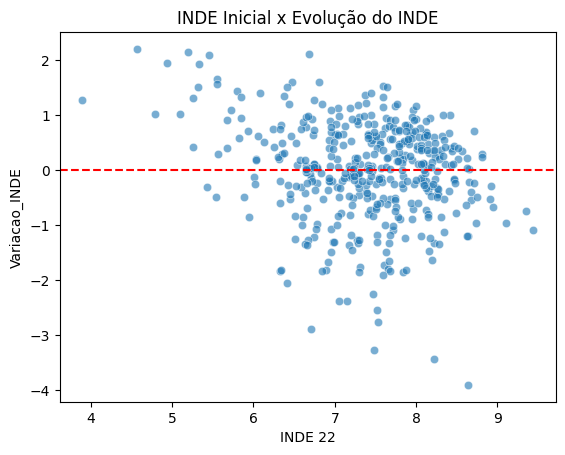

In [16]:
sns.scatterplot(
    data=evolucao,
    x='INDE 22',
    y='Variacao_INDE',
    alpha=0.6
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title('INDE Inicial x Evolução do INDE')

plt.show()

In [18]:
evolucao['Grupo_INDE_2022'] = pd.cut(
    evolucao['INDE 22'],
    bins=[0,6,8,10],
    labels=[
        'Baixo INDE',
        'Médio INDE',
        'Alto INDE'
    ]
)

evolucao.groupby('Grupo_INDE_2022')[
    'Variacao_INDE'
].mean().round(3)

/tmp/ipykernel_6031/3650961461.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  evolucao.groupby('Grupo_INDE_2022')[


,Variacao_INDE
Grupo_INDE_2022,
Baixo INDE,0.992
Médio INDE,-0.050
Alto INDE,-0.126


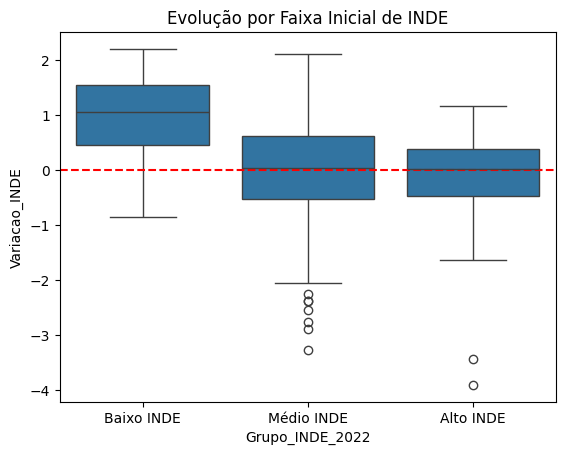

In [19]:
sns.boxplot(
    data=evolucao,
    x='Grupo_INDE_2022',
    y='Variacao_INDE'
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title('Evolução por Faixa Inicial de INDE')

plt.show()

## Evolução por Faixa Inicial de INDE

Os estudantes foram agrupados de acordo com seu INDE inicial em 2022.

| Grupo | Variação Média |
|---------|---------:|
| Baixo INDE | +0,992 |
| Médio INDE | -0,050 |
| Alto INDE | -0,126 |

### Insight Executivo

Os estudantes que iniciaram o programa com menores índices de desenvolvimento educacional apresentaram a maior evolução ao longo do período analisado.

A variação média próxima de +1 ponto de INDE observada no grupo de baixo desempenho sugere impacto mais expressivo justamente entre os alunos com maiores necessidades educacionais.

Esse resultado representa uma evidência relevante da efetividade do programa Passos Mágicos.

# Pergunta 11 - Insights e Criatividade

## Insight 11.1 - Evolução das Pedras

In [20]:
df2024_3anos[['RA','Pedra 22','Pedra 23','Pedra 2024']].head()

,RA,Pedra 22,Pedra 23,Pedra 2024
50,RA-702,Ametista,Topázio,Ametista
51,RA-725,Ágata,Topázio,Ametista
79,RA-858,Ametista,Ametista,Agata
84,RA-729,Topázio,Ametista,Agata
99,RA-754,Ágata,Agata,Quartzo


In [21]:
df2024_3anos['Pedra 2024'].value_counts()

,count
Pedra 2024,
Topázio,151
Ametista,135
Agata,103
Quartzo,52


In [23]:
ordem_pedras = {
    'Quartzo': 1,
    'Ágata': 2,
    'Ametista': 3,
    'Topázio': 4
}

In [24]:
pedras = df2024_3anos[
    ['RA','Pedra 22','Pedra 2024']
].copy()

pedras['Nivel_22'] = pedras['Pedra 22'].map(ordem_pedras)

pedras['Nivel_24'] = pedras['Pedra 2024'].map(ordem_pedras)

pedras['Variacao_Pedra'] = (
    pedras['Nivel_24']
    -
    pedras['Nivel_22']
)

pedras.head()

,RA,Pedra 22,Pedra 2024,Nivel_22,Nivel_24,Variacao_Pedra
50,RA-702,Ametista,Ametista,3,3.0,0.0
51,RA-725,Ágata,Ametista,2,3.0,1.0
79,RA-858,Ametista,Agata,3,NaN,NaN
84,RA-729,Topázio,Agata,4,NaN,NaN
99,RA-754,Ágata,Quartzo,2,1.0,-1.0


In [25]:
pedras['Variacao_Pedra'].value_counts().sort_index()

,count
Variacao_Pedra,
-3.0,2
-2.0,16
-1.0,51
0.0,150
1.0,106
2.0,13


In [26]:
print(
    "Evoluíram:",
    (pedras['Variacao_Pedra'] > 0).sum()
)

print(
    "Mantiveram:",
    (pedras['Variacao_Pedra'] == 0).sum()
)

print(
    "Regrediram:",
    (pedras['Variacao_Pedra'] < 0).sum()
)

Evoluíram: 119
Mantiveram: 150
Regrediram: 69


In [27]:
print(df2024_3anos['Pedra 22'].unique())
print()
print(df2024_3anos['Pedra 2024'].unique())

['Ametista' 'Ágata' 'Topázio' 'Quartzo']

['Ametista' 'Agata' 'Quartzo' 'Topázio' nan]


In [28]:
pedras_limpo = pedras.dropna(
    subset=['Nivel_22','Nivel_24']
).copy()

print(len(pedras_limpo))

338


In [29]:
print(
    "Evoluíram:",
    (pedras_limpo['Variacao_Pedra'] > 0).sum()
)

print(
    "Mantiveram:",
    (pedras_limpo['Variacao_Pedra'] == 0).sum()
)

print(
    "Regrediram:",
    (pedras_limpo['Variacao_Pedra'] < 0).sum()
)

Evoluíram: 119
Mantiveram: 150
Regrediram: 69


In [30]:
total = len(pedras_limpo)

print(
    f"% Evoluíram: {((pedras_limpo['Variacao_Pedra'] > 0).sum()/total)*100:.2f}%"
)

print(
    f"% Mantiveram: {((pedras_limpo['Variacao_Pedra'] == 0).sum()/total)*100:.2f}%"
)

print(
    f"% Regrediram: {((pedras_limpo['Variacao_Pedra'] < 0).sum()/total)*100:.2f}%"
)


% Evoluíram: 35.21%
% Mantiveram: 44.38%
% Regrediram: 20.41%


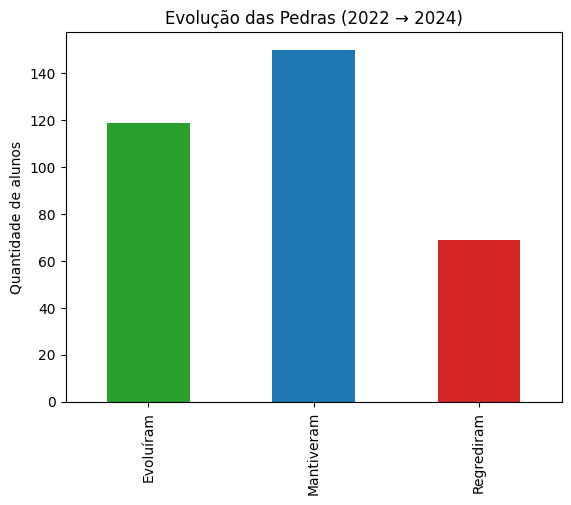

In [31]:
resultado_pedras = pd.Series({
    'Evoluíram': 119,
    'Mantiveram': 150,
    'Regrediram': 69
})

resultado_pedras.plot(
    kind='bar',
    color=['#2ca02c','#1f77b4','#d62728']
)

plt.title('Evolução das Pedras (2022 → 2024)')
plt.ylabel('Quantidade de alunos')

plt.show()

In [32]:
evolucao_pedra = pedras_limpo[['RA','Variacao_Pedra']].copy()

evolucao_pedra = evolucao_pedra.merge(
    evolucao[['RA','Variacao_INDE']],
    on='RA'
)

evolucao_pedra.groupby(
    'Variacao_Pedra'
)['Variacao_INDE'].mean().round(3)

,Variacao_INDE
Variacao_Pedra,
-3.0,-3.666
-2.0,-2.023
-1.0,-0.909
0.0,0.063
1.0,0.757
2.0,1.625


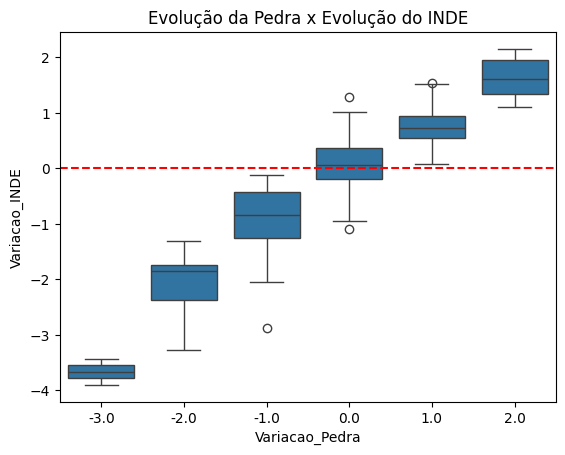

In [34]:
sns.boxplot(
    data=evolucao_pedra,
    x='Variacao_Pedra',
    y='Variacao_INDE'
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.title('Evolução da Pedra x Evolução do INDE')

plt.show()

## Insight 11.2 - Evolução das Pedras e Crescimento do INDE

Foi observada forte relação entre a evolução da Pedra e a evolução do INDE.

| Evolução da Pedra | Variação Média do INDE |
|----------|----------:|
| -3 | -3,666 |
| -2 | -2,023 |
| -1 | -0,909 |
| 0 | +0,063 |
| +1 | +0,757 |
| +2 | +1,625 |

### Insight Executivo

A progressão entre as Pedras reflete diretamente o desenvolvimento educacional dos estudantes.

Alunos que avançaram níveis de Pedra apresentaram ganhos consistentes de INDE, enquanto regressões de Pedra estiveram associadas a reduções do índice.

A classificação por Pedras se mostrou uma excelente síntese da trajetória educacional dos alunos ao longo do programa.
``